<a href="https://colab.research.google.com/github/salemAlaidaroos/Facial-Emotion-Recognition-PyTorch/blob/main/emotaion_dataSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import glob
from PIL import Image
import pandas as pd
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
import kagglehub


# Download latest version
path = kagglehub.dataset_download("sujaykapadnis/emotion-recognition-dataset")           # Data given in one folder unsplitted + csv

print("Path to dataset files:", path)

100%|██████████| 1.98G/1.98G [01:06<00:00, 31.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sujaykapadnis/emotion-recognition-dataset/versions/1


In [3]:
class_labels = {"Ahegao": 0, "Angry": 1, "Happy": 2, "Neutral": 3, "Sad": 4, "Surprise":5}

image_paths = []
labels = []
for class_name, label in class_labels.items():
    class_images = glob.glob(f"{path}/dataset/{class_name}/*.png")
    image_paths.extend(class_images)
    labels.extend([label] * len(class_images))


train_image , test_image , train_label, test_label =train_test_split(image_paths , labels , test_size=0.2 , shuffle = True , random_state=42)

In [4]:
class emotaion_data_set(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths=image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)  # Total number of images

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]  # Get image path
        label = self.labels[idx]  # Get label

        # Load image using PIL
        image = Image.open(image_path)

        # Apply transformations (if any)
        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])


transform_valid_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])

In [6]:
train_dataset = emotaion_data_set(train_image, train_label, transform= transform)
test_dataset = emotaion_data_set(test_image, test_label, transform= transform_valid_test)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=2)



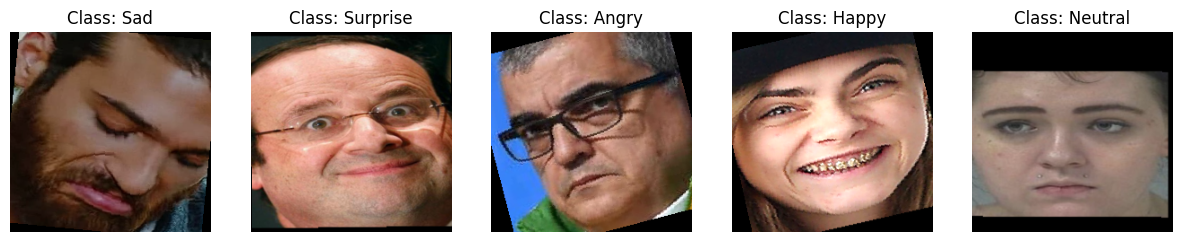

In [7]:
labels_class = {}
for k , v in class_labels.items():
  labels_class[v] = k


import matplotlib.pyplot as plt
import numpy as np

mean = np.array([0.5, 0.5, 0.5])
std = np.array([0.5, 0.5, 0.5])

fig, axes = plt.subplots(1, 5, figsize=(15, 5))

image_batch , label_batch = next(iter(train_loader))

for i in range(5):

    img = image_batch[i]
    img_np = img.numpy().transpose(1, 2, 0)

    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    label = label_batch[i].item()


    axes[i].imshow(img_np)

    axes[i].set_title(f'Class: {labels_class[label]}')
    axes[i].axis('off')

plt.show()
# labels_class



In [8]:
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, Labels: {labels}")

Batch shape: torch.Size([32, 3, 224, 224]), Labels: tensor([2, 0, 5, 2, 0, 3, 4, 1, 5, 4, 5, 2, 5, 3, 4, 1, 3, 1, 5, 1, 2, 0, 5, 0,
        5, 5, 1, 0, 3, 4, 1, 3])


In [9]:
from torchvision import models
import torch.nn as nn
import torch

model = models.efficientnet_b0(pretrained = True)
model.classifier[1] = nn.Linear(in_features= model.classifier[1].in_features, out_features= 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 209MB/s]


In [10]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)


        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Track accuracy
        predictions = torch.softmax(outputs, dim= 1)  # Get predicted class
        predictions = torch.argmax(predictions, dim= 1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

def validate(model, dataloader, criterion, device):

    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            predictions = torch.softmax(outputs, dim= 1)
            predictions = torch.argmax(predictions, dim= 1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


In [11]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Binary Classification loss (Use when there is no softmax/sigmoid in the last layer)
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Adam optimizer
num_epochs = 50 # Number of epochs


# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training process
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, test_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")


100%|██████████| 175/175 [00:51<00:00,  3.37it/s]


Epoch 1/50: Train Loss=1.2016, Train Accuracy=55.12%, Val Loss=0.7215, Val Accuracy=72.55%


100%|██████████| 175/175 [00:51<00:00,  3.43it/s]


Epoch 2/50: Train Loss=0.6702, Train Accuracy=74.91%, Val Loss=0.5181, Val Accuracy=80.34%


100%|██████████| 175/175 [00:51<00:00,  3.43it/s]


...

Epoch 48/50: Train Loss=0.0220, Train Accuracy=99.21%, Val Loss=0.8659, Val Accuracy=83.70%


100%|██████████| 175/175 [00:50<00:00,  3.46it/s]


Epoch 49/50: Train Loss=0.0189, Train Accuracy=99.36%, Val Loss=0.7980, Val Accuracy=84.13%


100%|██████████| 175/175 [00:51<00:00,  3.40it/s]


Epoch 50/50: Train Loss=0.0234, Train Accuracy=99.14%, Val Loss=0.7720, Val Accuracy=84.85%


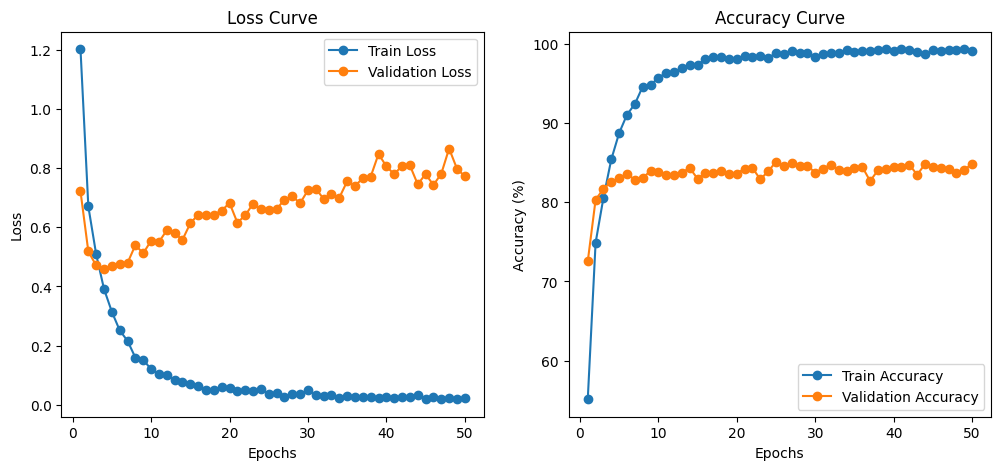

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.()

plt.show()


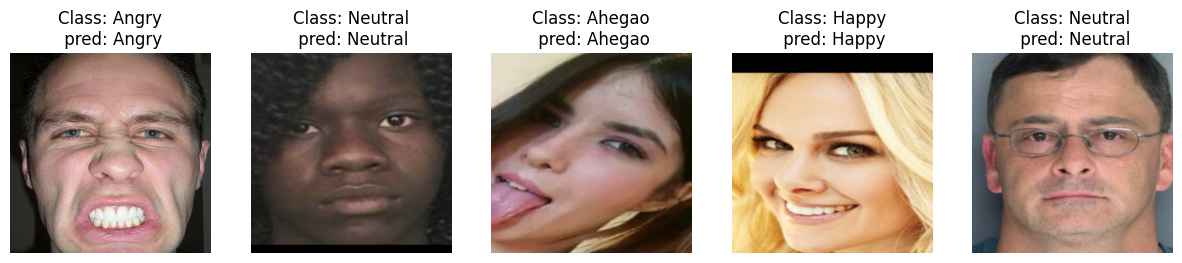

In [15]:
import numpy as np

def pred_VS_real(model , images , labels):
  model.eval()
  with torch.no_grad():
    model.to("cpu")
    images.to("cpu")
    output = model(images)
    images.to("cpu")
    predictions = torch.softmax(output, dim= 1)
    predictions = torch.argmax(predictions, dim= 1)


  mean = np.array([0.5, 0.5, 0.5])
  std = np.array([0.5, 0.5, 0.5])

  fig, axes = plt.subplots(1, 5, figsize=(15, 5))

  for i in range(5):

    img = images[i]
    img_np = img.numpy().transpose(1, 2, 0)

    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    label = labels[i].item()
    axes[i].imshow(img_np)

    axes[i].set_title(f'Class: {labels_class[label]}\n pred: {labels_class[predictions[i].item()]}')
    axes[i].axis('off')

  plt.show()

images , labels =next(iter(test_loader))

pred_VS_real(model ,images, labels )



